# **1. Introduction**

This notebook implements the full preprocessing pipeline based on the findings from **Notebook 01: Problem Understanding & EDA**.

### Preprocessing Steps Covered:
1. Drop `ID` column (not a predictive feature here, just a row index)
2. Rename target variable to `default`
3. Recode `EDUCATION` undocumented categories (0, 4, 5, 6 → 3)
4. Recode `MARRIAGE` undocumented category (0 → 3)
5. Log-transform `BILL_AMT` and `PAY_AMT` columns to handle extreme right skewness
6. One-hot encode categorical variables (`SEX`, `EDUCATION`, `MARRIAGE`)
7. Stratified 80/20 train-test split to preserve the 22% default rate
8. Scale continuous features with `StandardScaler`,  fit on train only (no data leakage)
9. Save processed datasets and the fitted scaler to disk

# **2. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# **3. Load Raw Data**

In [ ]:
BASE = r'C:\Users\jensd\Downloads\Datasets School\Data Science Map\credit-risk-project'

df = pd.read_csv(os.path.join(BASE, 'data', 'raw', 'UCI_Credit_Card.csv'))
print(f'Shape: {df.shape}')
df.head()

# **4. Data Cleaning**

## **4.1 Drop ID Column**

The `ID` column is just a row index — it carries no information about a customer's financial behaviour. Keeping it risks the model learning spurious patterns from row numbers.

In [3]:
df = df.drop(columns=['ID'])
print(f'ID dropped. New shape: {df.shape}')

ID dropped. New shape: (30000, 24)


## **4.2 Rename Target Variable**

Renaming `default.payment.next.month` to `default` for cleaner, less error-prone code throughout the rest of the pipeline.

In [4]:
df = df.rename(columns={'default.payment.next.month': 'default'})

print(f"Target renamed to 'default'")
print(f'\nClass distribution:')
print(df['default'].value_counts())
print(f'\nClass proportions:')
print(df['default'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Target renamed to 'default'

Class distribution:
default
0    23364
1     6636
Name: count, dtype: int64

Class proportions:
default
0    77.88%
1    22.12%
Name: proportion, dtype: object


## **4.3 Recode EDUCATION**

Per UCI documentation the valid categories are:
- `1` = graduate school
- `2` = university
- `3` = high school
- `4` = others
- `0`, `5`, `6` = undocumented / unknown

Values `0, 4, 5, 6` are all grouped into category `3` (other). Leaving them as separate categories would give the model meaningless signals from categories with no clear definition.

In [5]:
print('EDUCATION value counts BEFORE recoding:')
print(df['EDUCATION'].value_counts().sort_index())

df['EDUCATION'] = df['EDUCATION'].replace({0: 3, 4: 3, 5: 3, 6: 3})

print('\nEDUCATION value counts AFTER recoding:')
print(df['EDUCATION'].value_counts().sort_index())
print('\nValid categories: 1=graduate school, 2=university, 3=high school/other')

EDUCATION value counts BEFORE recoding:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

EDUCATION value counts AFTER recoding:
EDUCATION
1    10585
2    14030
3     5385
Name: count, dtype: int64

Valid categories: 1=graduate school, 2=university, 3=high school/other


## **4.4 Recode MARRIAGE**

Per UCI documentation the valid categories are:
- `1` = married
- `2` = single
- `3` = other
- `0` = undocumented

Value `0` is grouped into category `3` (other).

In [6]:
print('MARRIAGE value counts BEFORE recoding:')
print(df['MARRIAGE'].value_counts().sort_index())

df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

print('\nMARRIAGE value counts AFTER recoding:')
print(df['MARRIAGE'].value_counts().sort_index())
print('\nValid categories: 1=married, 2=single, 3=other')

MARRIAGE value counts BEFORE recoding:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

MARRIAGE value counts AFTER recoding:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

Valid categories: 1=married, 2=single, 3=other


## **4.5 Verify Payment Status (PAY) Column Values**

Checking the unique values in each PAY column. The UCI documentation does not fully define `-2` and `-1`, but based on common interpretation:
- `-2` = No consumption or balance paid in full
- `-1` = Payment made on time
- `0` = Use of revolving credit (minimum payment)
- `1–8` = Payment delayed by N months

These follow a meaningful ordinal pattern and are **kept as-is** — they are the strongest predictors of default (PAY_0 r=0.32 from EDA).

In [7]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

for col in pay_cols:
    print(f'{col}: {sorted(df[col].unique())}')

PAY_0: [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_2: [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_3: [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_4: [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_5: [-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]
PAY_6: [-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]


# **5. Feature Engineering — Log Transformation of BILL_AMT and PAY_AMT**

From EDA:
- `BILL_AMT` columns: heavily right-skewed with ~8% outliers
- `PAY_AMT` columns: extremely right-skewed with ~9% outliers and many zeros

**Why log transform?**
A small number of customers have extreme values that dominate the scale. Log compression brings those extreme values in without removing them, so the model treats relative differences (e.g. 100 vs 1,000) as more meaningful than absolute differences (e.g. 100,000 vs 101,000). This is more appropriate for financial data.

**Two approaches:**
- `PAY_AMT` → `log1p(x)` = log(1 + x): handles zeros safely, always ≥ 0
- `BILL_AMT` → signed log: `sign(x) * log1p(|x|)`: handles negative values caused by customer overpayments (credit balance on statement)

In [8]:
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# Signed log for BILL_AMT: preserves negative values from customer overpayments
for col in bill_cols:
    df[col] = np.sign(df[col]) * np.log1p(np.abs(df[col]))

# log1p for PAY_AMT: always >= 0, handles zeros safely
for col in pay_amt_cols:
    df[col] = np.log1p(df[col])

print('Log transformation applied.')
df[bill_cols + pay_amt_cols].describe().round(3)

Log transformation applied.


,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000
mean,8.948,8.739,8.610,8.451,8.288,8.076,6.630,6.563,6.283,6.078,6.032,5.933
std,3.562,3.810,3.907,3.992,4.058,4.221,3.250,3.279,3.350,3.397,3.444,3.528
min,-12.017,-11.153,-11.966,-12.044,-11.306,-12.736,0.000,0.000,0.000,0.000,0.000,0.000
25%,8.177,8.002,7.889,7.753,7.475,7.136,6.909,6.726,5.969,5.694,5.535,4.777
50%,10.016,9.962,9.908,9.855,9.804,9.745,7.650,7.606,7.496,7.314,7.314,7.314
75%,11.114,11.067,11.005,10.906,10.824,10.804,8.519,8.517,8.413,8.298,8.302,8.294
max,13.779,13.799,14.325,13.701,13.740,13.776,13.680,14.337,13.706,13.339,12.963,13.178


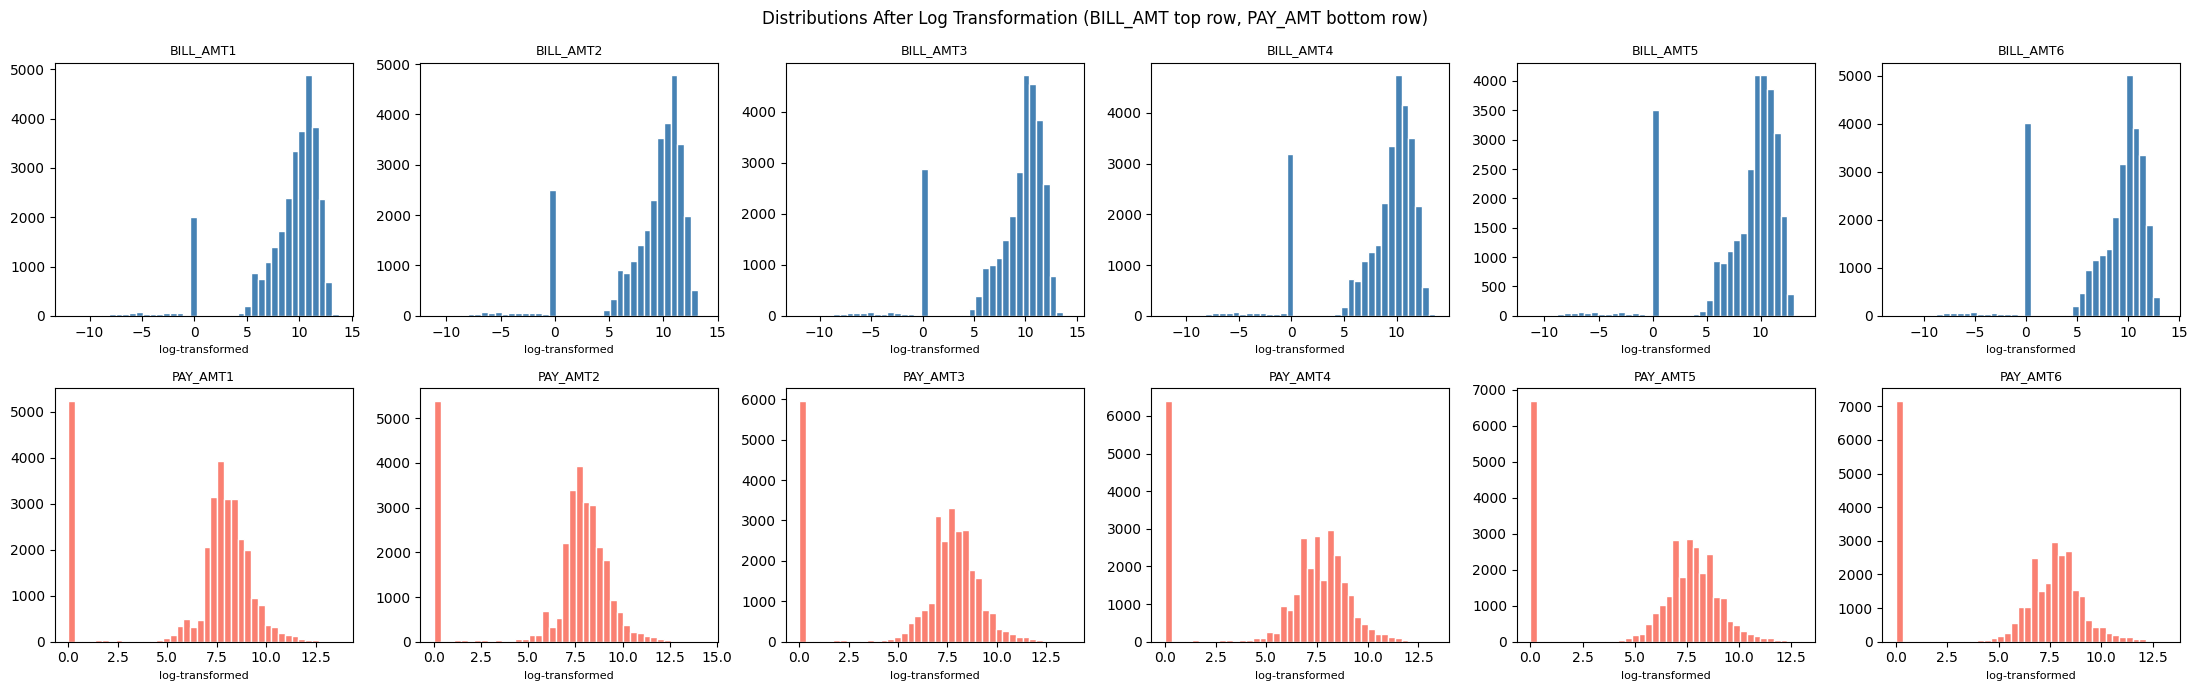

In [9]:
fig, axes = plt.subplots(2, 6, figsize=(22, 7))

for i, col in enumerate(bill_cols):
    axes[0, i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[0, i].set_title(col, fontsize=9)
    axes[0, i].set_xlabel('log-transformed', fontsize=8)

for i, col in enumerate(pay_amt_cols):
    axes[1, i].hist(df[col], bins=40, color='salmon', edgecolor='white')
    axes[1, i].set_title(col, fontsize=9)
    axes[1, i].set_xlabel('log-transformed', fontsize=8)

plt.suptitle('Distributions After Log Transformation (BILL_AMT top row, PAY_AMT bottom row)', fontsize=12)
plt.tight_layout()
plt.show()

# **6. Save Interim Data**

Saving a checkpoint of the data after cleaning and log transformation, but **before** encoding and scaling. Useful if you want to resume from this point or do further exploration without re-running all the cleaning steps.

In [10]:
interim_path = os.path.join(BASE, 'data', 'interim', 'credit_interim.csv')
df.to_csv(interim_path, index=False)
print(f'Interim data saved: {interim_path}')
print(f'Shape: {df.shape}')

Interim data saved: C:\Users\jensd\Downloads\Datasets School\Data Science Map\credit-risk-project\data\interim\credit_interim.csv
Shape: (30000, 24)


# **7. Feature Selection**

## **7.1 Multicollinearity Check**

From EDA, two groups of features were flagged as highly correlated:
- `BILL_AMT1–6`: monthly balances carry over month to month, so consecutive months are strongly correlated
- `PAY_0, PAY_2–6`: similar payment behaviour across months

We visualise the correlation to quantify this and then make a decision.

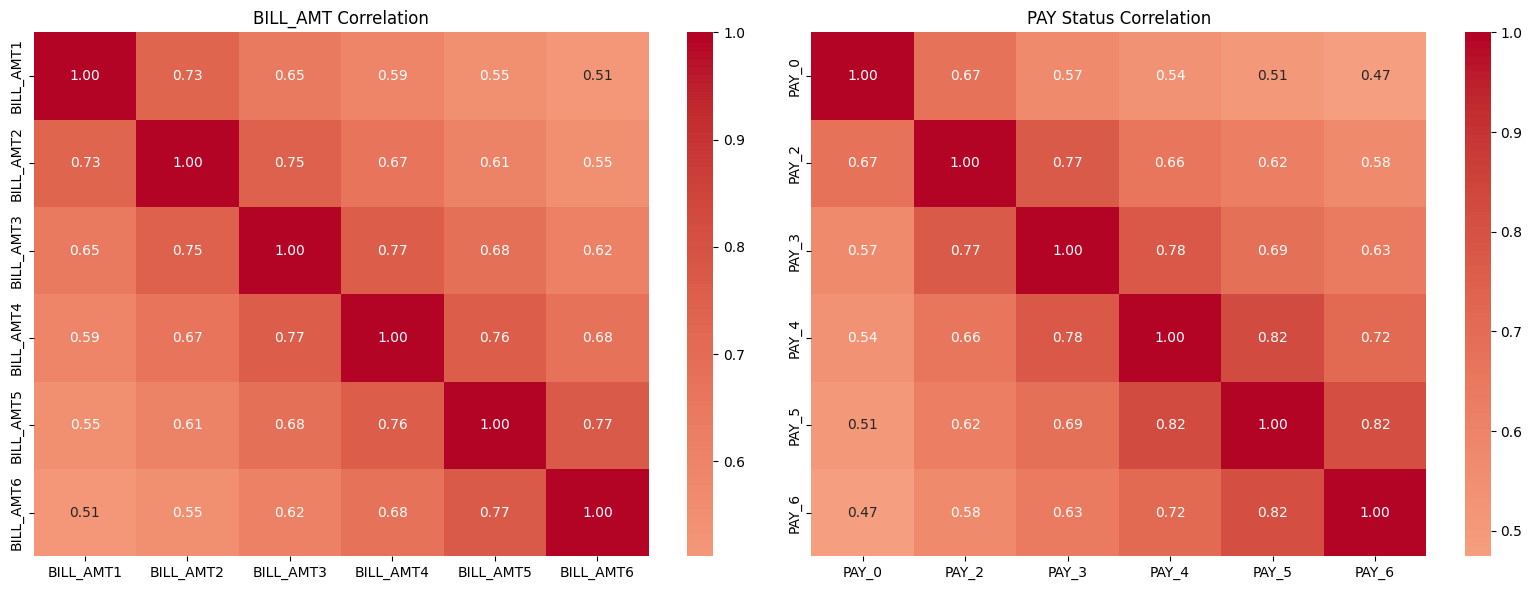

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(df[bill_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('BILL_AMT Correlation')

sns.heatmap(df[pay_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('PAY Status Correlation')

plt.tight_layout()
plt.show()

## **7.2 Decision: Retain All Features**

| Option | Pros | Cons |
|--------|------|------|
| Keep all features | Simple; tree-based models handle multicollinearity naturally | Linear models may be unstable |
| Drop correlated columns | Simpler model | Arbitrary choice, information loss |
| PCA | Fully removes multicollinearity | Loses feature names and interpretability |

**Decision:** Retain all features. The planned models in Notebook 03 (Random Forest, XGBoost) are tree-based and inherently robust to multicollinearity. Feature importance scores from those models will reveal if any columns are truly redundant. If a logistic regression baseline is added, PCA or VIF-based selection can be revisited at that point.

# **8. Encoding — One-Hot Encode Categorical Variables**

`SEX`, `EDUCATION`, and `MARRIAGE` are stored as integers but are nominal categories — their numeric codes have no real order (e.g. MARRIAGE 1 is not mathematically "less than" MARRIAGE 2). We convert them into binary columns so the model treats them correctly.

Using `drop_first=True` to avoid the dummy variable trap — if a feature has 3 categories, you only need 2 binary columns to represent it. The third is implied when both are 0.

| Feature | Values | Columns created |
|---------|--------|-----------------|
| SEX | 1=male, 2=female | `SEX_2` |
| EDUCATION | 1=grad, 2=university, 3=other | `EDUCATION_2`, `EDUCATION_3` |
| MARRIAGE | 1=married, 2=single, 3=other | `MARRIAGE_2`, `MARRIAGE_3` |

In [12]:
df = pd.get_dummies(df, columns=['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True)

new_cols = [c for c in df.columns if any(x in c for x in ['SEX_', 'EDUCATION_', 'MARRIAGE_'])]
print(f'Shape after encoding: {df.shape}')
print(f'New columns created: {new_cols}')
df.head(2)

Shape after encoding: (30000, 26)
New columns created: ['SEX_2', 'EDUCATION_2', 'EDUCATION_3', 'MARRIAGE_2', 'MARRIAGE_3']


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default,SEX_2,EDUCATION_2,EDUCATION_3,MARRIAGE_2,MARRIAGE_3
0,20000.0,24,2,2,-1,-1,-2,-2,8.272315,8.040125,...,0.000000,0.000000,0.0,0.000000,1,True,True,False,False,False
1,120000.0,26,-1,2,0,0,0,2,7.894691,7.453562,...,6.908755,6.908755,0.0,7.601402,1,True,True,False,True,False


# **9. Train-Test Split**

Splitting the data into 80% train and 20% test before scaling. The split must happen **before** scaling — the scaler needs to be fit on training data only.

Using `stratify=y` to ensure both sets preserve the original 22% default rate. Without it, a random split could under- or over-represent defaults in one set, which would distort model evaluation.

In [13]:
X = df.drop(columns=['default'])
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

print(f'Training set : {X_train.shape[0]:,} samples ({X_train.shape[0] / len(df) * 100:.1f}%)')
print(f'Test set     : {X_test.shape[0]:,} samples ({X_test.shape[0] / len(df) * 100:.1f}%)')
print(f'Features     : {X_train.shape[1]}')
print(f'\nClass distribution — TRAIN:')
print(y_train.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
print(f'\nClass distribution — TEST:')
print(y_test.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Training set : 24,000 samples (80.0%)
Test set     : 6,000 samples (20.0%)
Features     : 25

Class distribution — TRAIN:
default
0    77.88%
1    22.12%
Name: proportion, dtype: object

Class distribution — TEST:
default
0    77.88%
1    22.12%
Name: proportion, dtype: object


# **10. Feature Scaling**

Using `StandardScaler` to scale continuous numeric features to mean=0 and std=1.

**Why scale?** Features like `LIMIT_BAL` range up to 1,000,000 while `AGE` ranges 20–80. Models that use distance or gradients (logistic regression, neural nets) are sensitive to this — larger-scaled features dominate. Scaling puts all features on equal footing.

**Critical — no data leakage:** The scaler is fit on `X_train` only, then applied to both sets. Fitting on the full dataset would let test-set statistics influence the scaler, making the test set no longer truly unseen.

**What we scale:** `LIMIT_BAL`, `AGE`, all `BILL_AMT*`, all `PAY_AMT*`, all `PAY_*` status columns.
**What we don't scale:** the one-hot encoded columns (`SEX_2`, `EDUCATION_2/3`, `MARRIAGE_2/3`) — they are already binary (0 or 1).

In [14]:
cols_to_scale = ['LIMIT_BAL', 'AGE'] + bill_cols + pay_amt_cols + pay_cols

# Copy to avoid pandas SettingWithCopyWarning
X_train = X_train.copy()
X_test = X_test.copy()

scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])  # fit + transform on train
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])         # transform only on test

print(f'Scaled {len(cols_to_scale)} columns.')
print(f'\nTrain mean (should be ~0):')
print(X_train[cols_to_scale].mean().round(3))
print(f'\nTrain std (should be ~1):')
print(X_train[cols_to_scale].std().round(3))

Scaled 20 columns.

Train mean (should be ~0):
LIMIT_BAL    0.0
AGE         -0.0
BILL_AMT1   -0.0
BILL_AMT2    0.0
BILL_AMT3    0.0
BILL_AMT4    0.0
BILL_AMT5   -0.0
BILL_AMT6   -0.0
PAY_AMT1    -0.0
PAY_AMT2     0.0
PAY_AMT3    -0.0
PAY_AMT4     0.0
PAY_AMT5     0.0
PAY_AMT6     0.0
PAY_0       -0.0
PAY_2        0.0
PAY_3        0.0
PAY_4        0.0
PAY_5        0.0
PAY_6       -0.0
dtype: float64

Train std (should be ~1):
LIMIT_BAL    1.0
AGE          1.0
BILL_AMT1    1.0
BILL_AMT2    1.0
BILL_AMT3    1.0
BILL_AMT4    1.0
BILL_AMT5    1.0
BILL_AMT6    1.0
PAY_AMT1     1.0
PAY_AMT2     1.0
PAY_AMT3     1.0
PAY_AMT4     1.0
PAY_AMT5     1.0
PAY_AMT6     1.0
PAY_0        1.0
PAY_2        1.0
PAY_3        1.0
PAY_4        1.0
PAY_5        1.0
PAY_6        1.0
dtype: float64


# **11. Save Processed Data**

Saving the final train/test splits and the fitted scaler.

The scaler must be saved alongside the model — when a new customer's data comes in at inference time, it needs to be transformed using the exact same mean and std from the training set before being passed to the model.

In [15]:
processed_dir = os.path.join(BASE, 'data', 'processed')

X_train.to_csv(os.path.join(processed_dir, 'X_train.csv'), index=False)
X_test.to_csv(os.path.join(processed_dir, 'X_test.csv'), index=False)
y_train.to_csv(os.path.join(processed_dir, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(processed_dir, 'y_test.csv'), index=False)

scaler_path = os.path.join(BASE, 'models', 'scaler.pkl')
joblib.dump(scaler, scaler_path)

print('Processed datasets saved:')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  y_train : {y_train.shape}')
print(f'  y_test  : {y_test.shape}')
print(f'\nScaler saved: {scaler_path}')

Processed datasets saved:
  X_train : (24000, 25)
  X_test  : (6000, 25)
  y_train : (24000,)
  y_test  : (6000,)

Scaler saved: C:\Users\jensd\Downloads\Datasets School\Data Science Map\credit-risk-project\models\scaler.pkl


# **12. Summary**

### What was done:

| Step | Action | Reason |
|------|--------|--------|
| Drop ID | Removed row index column | Not a predictive feature |
| Rename target | `default.payment.next.month` → `default` | Cleaner code |
| Recode EDUCATION | Grouped 0, 4, 5, 6 → 3 | Remove undocumented categories |
| Recode MARRIAGE | Grouped 0 → 3 | Remove undocumented category |
| Log transform BILL_AMT | Signed log1p | Handle right skew + negative overpayment values |
| Log transform PAY_AMT | log1p | Handle extreme right skew and zeros |
| One-hot encoding | SEX, EDUCATION, MARRIAGE with drop_first | Proper categorical treatment |
| Stratified split | 80/20, stratify=y, random_state=0 | Preserve 22% default rate in both sets |
| StandardScaler | Fit on train only, transform both | Normalize scale, prevent data leakage |

### Output files:
- `data/interim/credit_interim.csv` — cleaned + log-transformed, before encoding/scaling
- `data/processed/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` — model-ready splits
- `models/scaler.pkl` — fitted scaler for inference

### Next steps (Notebook 03 — Modeling & Evaluation):
- Train baseline model (Logistic Regression)
- Train main models (Random Forest, XGBoost)
- Address class imbalance with `class_weight='balanced'` or SMOTE
- Evaluate with AUC-ROC, Recall, and Precision-Recall curve — not accuracy (data is imbalanced)